# Batched Rendering


Currently, for batched processing with BATSim, we recomend setting ``OMP`` threads to 1 and using Python multiprocessing. This is because by default Galsim's C++ sampler will try and multi-thread, and for large samples, processing a single galaxy per thread is usually fastest.

Be aware that ``OMP`` threads must be set **before** Galsim is imported.

In [1]:
import os

# This is the key part, and must be run BEFORE Galsim imports
original_omp_threads = os.environ.get('OMP_NUM_THREADS', None)
os.environ['OMP_NUM_THREADS'] = '1'

import batsim
import galsim
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing import Pool, cpu_count
from time import time

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

Let's start by generating a set of 100 Sersic galaxy profiles using Galsim. To keep things simple, we'll randomly sample a range of half-light radii and Sersic indices from a uniform distribution.

In [2]:
n_gals = 100

# Set morphological parameters to sample over
hlr_vec = np.random.uniform(0.15, 1.5, n_gals)
n_vec = np.random.uniform(0.3, 6, n_gals) # allowed range of Galsim values
intrinsic_e1 = np.random.uniform(-0.5, 0.5, n_gals)
intrinsic_e2 = np.random.uniform(-0.5, 0.5, n_gals)

# Construct list containing GSObjects for parameter combinations
gal_list = []
for i in range(len(hlr_vec)):
    gal_list.append(
        galsim.Sersic(
            half_light_radius=hlr_vec[i], n=n_vec[i]
        ).shear( # give the galaxies some random intrinsic ellipticity
            e1=intrinsic_e1[i], e2=intrinsic_e2[i] 
        )
    )

# Define PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

By now, you should be familiar with BATSim's usage and transforms, so lets look at something new: the ability to pass multiple transforms as a sequence.

When multiple transforms are passed, the are applied in the order they appear in the sequence. Consider we wish to simulate a weak lensing survey with intrinsic alignments. Since IA is a physical distortion, we must apply this transform first, followed by the lensing, as this is an image level effect.

Because BATSim's IA shear is calculated as a function of half-light radius, we need to be smart about how we construct this multiprocessing pool.

In [3]:
# Define image parameters
npix = 128
pix_scale = 0.2
lens_shear = 0.02

# define a function to parallelise
def batch_batsim(
        gal_obj,
        ngrid,
        scale,
        psf_obj,
        lens_shear,
        hlr
    ):

    # Instantiate ia_transform based on HLR using default G19 fit
    # ampltiude and power
    ia_transform = batsim.IATransform(
        hlr=hlr,
        scale=scale
    )

    # Instantiate lensing transform
    lens_transform = batsim.LensTransform(
        gamma1=lens_shear,
        gamma2=0,
        kappa=0
    )

    # Call BATSim render passing both transform objects
    gal_img = batsim.simulate_galaxy(
        gal_obj=gal_obj,
        ngrid=ngrid,
        scale=scale,
        transform_obj=[ia_transform, lens_transform],
        psf_obj=psf_obj
    )

    # BATSim returns np.array(), but we return a galsim.Image here
    # to make stiching the individual stamps easier later
    return galsim.ImageF(gal_img)

For multiprocessing, we will use an arguemnt list and ``Pool.starmap`` to allow multiple arguments to be passed. Unfortunately, despite ``LensTransform`` being the same for all galaxies, we cannot pass the object itself to multiprocessing, so instead we instantiate it inside each worker.

In [4]:
# append function args into list for parallel processing
arg_list = []
for i in range(len(gal_list)):
    arg_list.append([gal_list[i], npix, pix_scale, psf, lens_shear, hlr_vec[i]])

# Set-up pool
start = time()
with Pool(processes=cpu_count()//2) as p: # Don't use more than half the available CPUs

    # pass function and iterables to be parallel processed
    gal_images = p.starmap(func=batch_batsim, iterable=arg_list)
end = time()

# Get timing metrics
ptime = end-start
t_per_gal = ptime / n_gals # CPU core seconds, since we force 1 gal per thread
print("CPU seconds per galaxy:", t_per_gal)

CPU seconds per galaxy: 1.011086254119873


Let's stich the results together using ``batsim.pltutil`` and inspect...

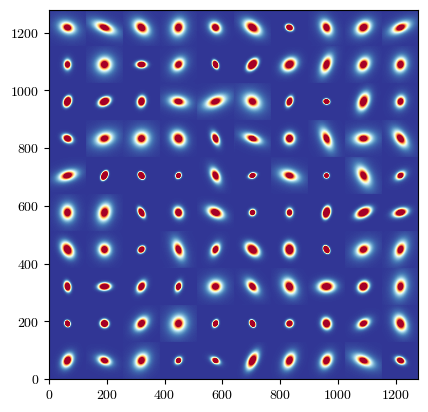

In [5]:
# BATSim pltutil includes a function for stitching lists of images into a single
# galsim.Image
gal_scene = batsim.pltutil.stitch_images(gal_images, direction="square")
fig = batsim.pltutil.make_plot_image(gal_scene.array)

And that covers batch simulating samples of galaxies with BATSim. You should observe the simulation of the 100 galaxies used here takes about 0.5 CPU core seconds per galaxy. This is evidently much slower than Galsim and we do hope to improve upon this in future, however, it is sufficient for simulating samples on the order of hundreds of thousands of galaxies with a single HPC node.

For example, if you wished to generate a large weak lensing sample with intrinsic alignments, we would suggest using Galsim to handle the majority of the processing and only processing the fraction of galaxies which you wish to be intrinsically aligned with BATSim.